In [2]:
import pandas as ps
import numpy as np

In [ ]:
c = ps.read_excel("<YOUR_PATH_HERE>/Personal_project.xlsx\")
c.head(5)

,DATE,NUMBER_OF_BUNDLES,NUMBER_OF_LEAVES,Bill Number,Bill date
0,2021-02-13,9.0,4500.0,1.0,2021-03-06 00:00:00
1,2021-02-14,0.0,0.0,0.0,0
2,2021-02-15,0.0,0.0,0.0,0
3,2021-02-16,0.0,0.0,0.0,0
4,2021-02-17,0.0,0.0,0.0,0


In [4]:
c.shape


(1964, 5)

In [10]:
c.dtypes

DATE                 datetime64[ns]
NUMBER_OF_BUNDLES           float64
NUMBER_OF_LEAVES            float64
Bill Number                 float64
Bill date                    object
dtype: object

In [11]:
c.describe()

,DATE,NUMBER_OF_BUNDLES,NUMBER_OF_LEAVES,Bill Number
count,1964,1936.000000,1936.000000,1934.000000
mean,2023-10-22 12:00:00,4.160640,2080.320248,102.933816
min,2021-02-13 00:00:00,0.000000,0.000000,0.000000
25%,2022-06-18 18:00:00,0.000000,0.000000,0.000000
50%,2023-10-22 12:00:00,0.000000,0.000000,0.000000
75%,2025-02-24 06:00:00,6.000000,3000.000000,150.000000
max,2026-06-30 00:00:00,24.000000,12000.000000,628.000000
std,NaN,6.546239,3273.119730,173.575809


In [13]:
c[c["NUMBER_OF_BUNDLES"] >0].shape[0]

750

In [14]:
delivery_days = c[c["NUMBER_OF_BUNDLES"] > 0]

In [15]:
print(delivery_days["NUMBER_OF_BUNDLES"].mean())

10.74


In [19]:
c['Month'] = c['DATE'].dt.month
monthly = c.groupby('Month')['NUMBER_OF_BUNDLES'].sum()
print(monthly)

Month
1     586.0
2     612.0
3     783.0
4     774.0
5     825.0
6     788.0
7     562.0
8     561.0
9     579.0
10    677.0
11    608.0
12    700.0
Name: NUMBER_OF_BUNDLES, dtype: float64


In [22]:
c['Year'] = c['DATE'].dt.year
yearly =  c.groupby('Year')['NUMBER_OF_BUNDLES'].sum()
print(yearly)

Year
2021     639.0
2022    1210.0
2023    1135.0
2024    2064.0
2025    1850.0
2026    1157.0
Name: NUMBER_OF_BUNDLES, dtype: float64


In [23]:
monthly1 = c.groupby(['Year' , 'Month'])['NUMBER_OF_BUNDLES'].sum()
print("\nMonthly per year :" )
print(monthly1)


Monthly per year :
Year  Month
2021  2         31.0
      3         68.0
      4         57.0
      5         19.0
      6         28.0
               ...  
2026  2        184.0
      3        234.0
      4        181.0
      5        203.0
      6        188.0
Name: NUMBER_OF_BUNDLES, Length: 65, dtype: float64


In [25]:
ps.set_option('display.max_rows', 100)

In [31]:
a = c.groupby(['Month' , 'Year'])["NUMBER_OF_BUNDLES"].sum().unstack(fill_value=0)
# a.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(a)
print("\nYearly totals:")
print(a.sum(axis=1))

Year   2021   2022   2023   2024   2025   2026
Month                                         
1       0.0   42.0   82.0  136.0  159.0  167.0
2      31.0   80.0   77.0  138.0  102.0  184.0
3      68.0  108.0   95.0  133.0  145.0  234.0
4      57.0  108.0  110.0  165.0  153.0  181.0
5      19.0  128.0  113.0  186.0  176.0  203.0
6      28.0  138.0   91.0  217.0  126.0  188.0
7      45.0  153.0   87.0  167.0  110.0    0.0
8      64.0   96.0  107.0  153.0  141.0    0.0
9      44.0  104.0   85.0  176.0  170.0    0.0
10     96.0   80.0  108.0  209.0  184.0    0.0
11     91.0   85.0   69.0  172.0  191.0    0.0
12     96.0   88.0  111.0  212.0  193.0    0.0

Yearly totals:
Month
1     586.0
2     612.0
3     783.0
4     774.0
5     825.0
6     788.0
7     562.0
8     561.0
9     579.0
10    677.0
11    608.0
12    700.0
dtype: float64


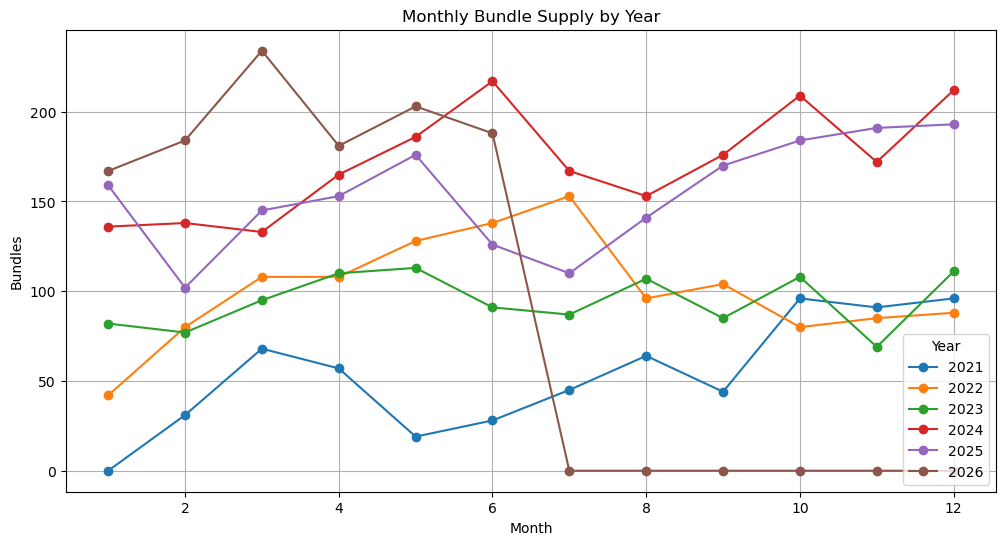

In [33]:
a.plot(figsize=(12,6), marker='o')
plt.title('Monthly Bundle Supply by Year')
plt.xlabel('Month')
plt.ylabel('Bundles')
plt.legend(title='Year')
plt.grid(True)
plt.show()

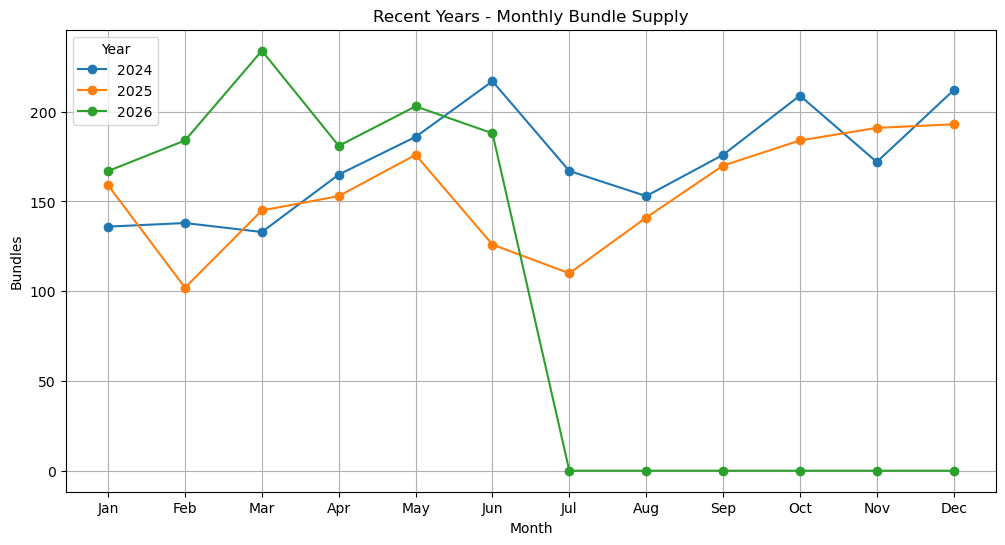

In [34]:
a[[2024, 2025, 2026]].plot(figsize=(12,6), marker='o')
plt.title('Recent Years - Monthly Bundle Supply')
plt.xlabel('Month')
plt.ylabel('Bundles')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May',
                          'Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Year')
plt.grid(True)
plt.show()

DAY_OF_WEEK
Monday       1157.0
Tuesday      1217.0
Wednesday    1176.0
Thursday      999.0
Friday       1044.0
Saturday     1240.0
Sunday       1222.0
Name: NUMBER_OF_BUNDLES, dtype: float64


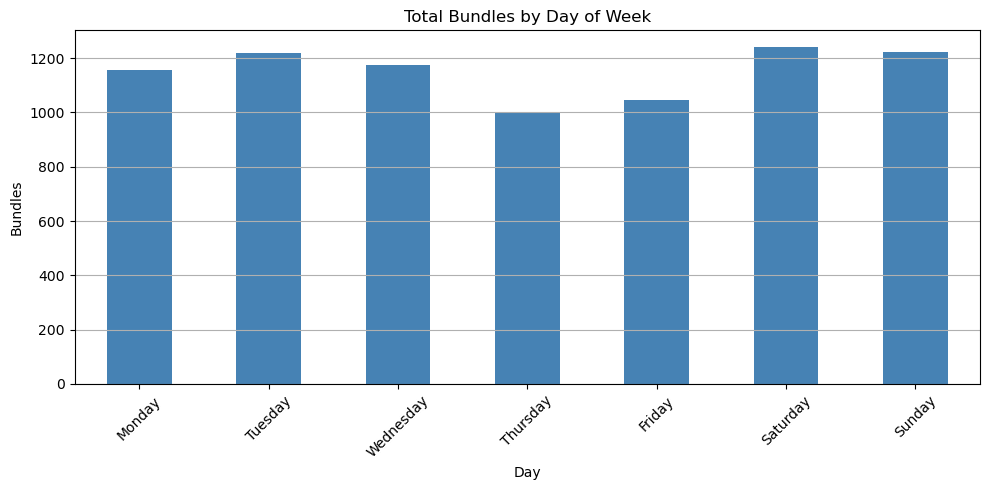

In [35]:
c['DAY_OF_WEEK'] = c['DATE'].dt.day_name()

day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']

day_analysis = c.groupby('DAY_OF_WEEK')['NUMBER_OF_BUNDLES']\
                .sum().reindex(day_order)
print(day_analysis)

day_analysis.plot(kind='bar', figsize=(10,5), color='steelblue')
plt.title('Total Bundles by Day of Week')
plt.xlabel('Day')
plt.ylabel('Bundles')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

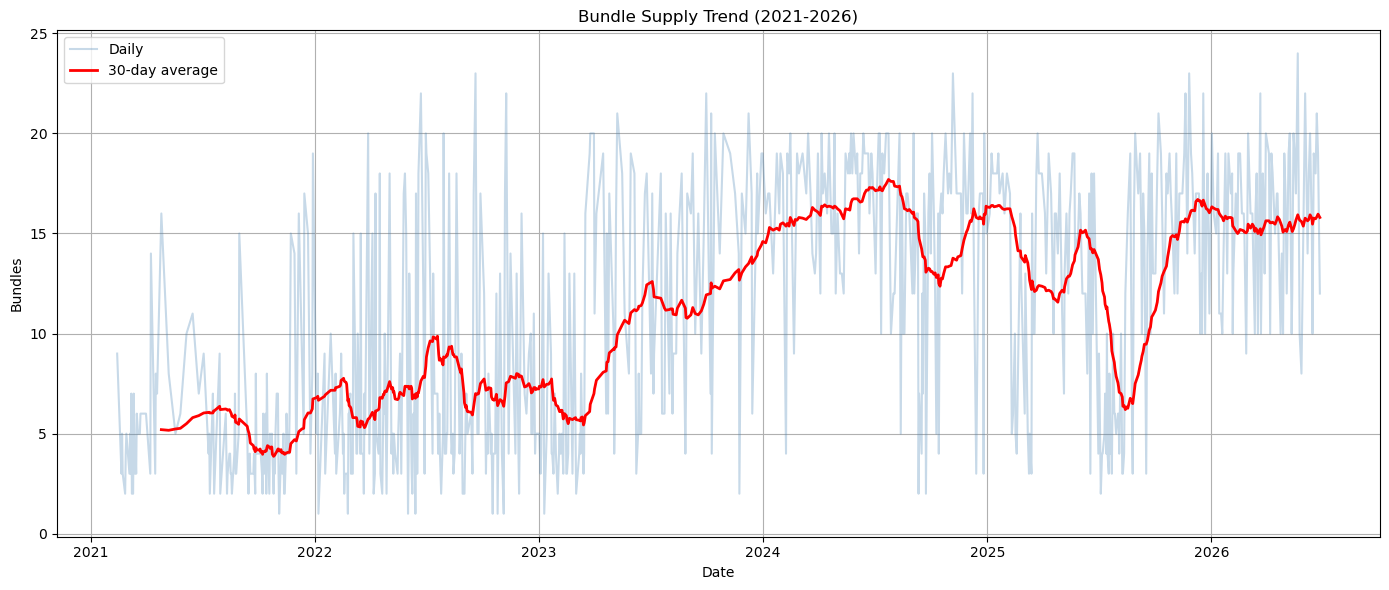

In [36]:
# Only delivery days
delivery = c[c['NUMBER_OF_BUNDLES'] > 0].copy()
delivery = delivery.sort_values('DATE')

# 30 day rolling average
delivery['ROLLING_30'] = delivery['NUMBER_OF_BUNDLES'].rolling(30).mean()

plt.figure(figsize=(14,6))
plt.plot(delivery['DATE'], delivery['NUMBER_OF_BUNDLES'], 
         alpha=0.3, color='steelblue', label='Daily')
plt.plot(delivery['DATE'], delivery['ROLLING_30'], 
         color='red', linewidth=2, label='30-day average')
plt.title('Bundle Supply Trend (2021-2026)')
plt.xlabel('Date')
plt.ylabel('Bundles')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()